# Importing Libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import seaborn as sns
import math

In [4]:
df = pd.read_excel("/content/sample_data/yahoo_data.xlsx")

# EDA

In [5]:
df.head()


,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close*,Adj Close**,Volume
Date,,,,,,
2023-04-28,33797.43,34104.56,33728.40,34098.16,34098.16,354310000
2023-04-27,33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2023-04-26,33596.34,33645.83,33235.85,33301.87,33301.87,321170000
2023-04-25,33828.34,33875.49,33525.39,33530.83,33530.83,297880000
2023-04-24,33805.04,33891.15,33726.09,33875.40,33875.40,252020000


In [5]:
print(df.isnull().sum())

Open           0
High           0
Low            0
Close*         0
Adj Close**    0
Volume         0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2023-04-28 to 2018-05-01
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Open         1258 non-null   float64
 1   High         1258 non-null   float64
 2   Low          1258 non-null   float64
 3   Close*       1258 non-null   float64
 4   Adj Close**  1258 non-null   float64
 5   Volume       1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


# Data Visualization

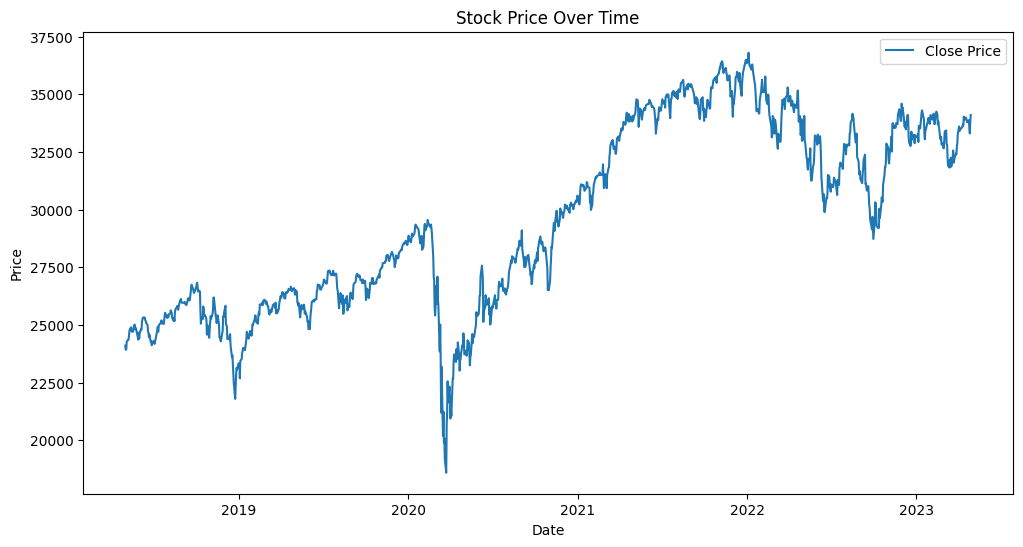

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df['Adj Close**'], label='Close Price')
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## Scaling the Data

In [7]:
adj_scaler = MinMaxScaler()
df['Adj Close**'] = adj_scaler.fit_transform(df[['Adj Close**']])

# Time Series Model

In [8]:
def create_dataset(dataset, look_back=30):
  X, Y = [], []
  for i in range(len(dataset) - look_back):
    X.append(dataset[i:i + look_back])
    Y.append(dataset[i + look_back, 0])  # target = Adj Close
  return np.array(X), np.array(Y).reshape(-1, 1)

In [9]:
data = df[['Adj Close**']].values
X, Y = create_dataset(data, look_back=30)

## Train-Test Split

In [10]:
trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)

 ## Model Training

In [16]:
model = Sequential()
model.add(LSTM(50, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(trainX, trainY, epochs=500, batch_size=32,
                    validation_split=0.2, verbose=0, callbacks=[early_stop])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

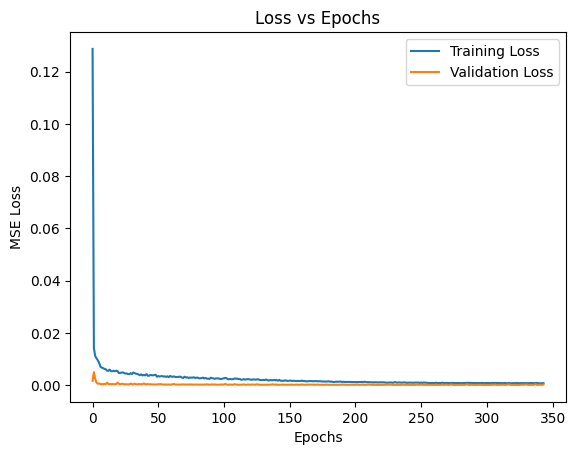

In [17]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.show()

The graph shows that both training and validation loss decrease steadily as epochs increase, indicating effective learning.
The validation loss stays lower and stable, suggesting the model is generalizing well without overfitting.

## Model Testing and Performance measuring

In [18]:
Y_pred = model.predict(testX)
Y_pred = adj_scaler.inverse_transform(Y_pred)
Y_test_rescaled = adj_scaler.inverse_transform(testY)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


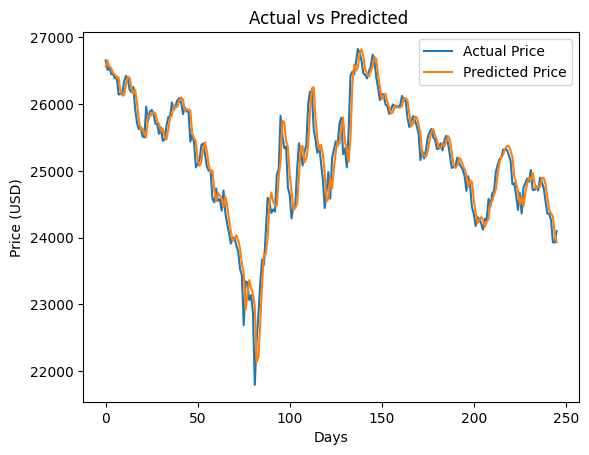

In [19]:
plt.plot(Y_test_rescaled, label='Actual Price')
plt.plot(Y_pred, label='Predicted Price')
plt.title("Actual vs Predicted ")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [20]:
# --- Metrics ---
rmse = np.sqrt(mean_squared_error(Y_test_rescaled, Y_pred))
mae = mean_absolute_error(Y_test_rescaled, Y_pred)
r2 = r2_score(Y_test_rescaled, Y_pred)
mape = np.mean(np.abs((Y_test_rescaled - Y_pred) / Y_test_rescaled)) * 100

print('RMSE', rmse)
print('MAE', mae)
print('R2', r2)
print('MAPE in %', mape)

RMSE 246.56532227519347
MAE 180.8480424288618
R2 0.9212965858973353
MAPE in % 0.7266625682314166


# Model performance:


1. RMSE ~ 246.5 (~0.91% of mid-range price 27k): On average, predictions deviate by ~246 units. Ideal: as low as possible.
2. MAE  ~ 180.8 (~0.67% of mid-range price 27k): Average absolute error between predictions and actual values. Ideal: as low as possible.
3. R²   ~ 0.921: Model explains ~92% of variance in data. Ideal: close to 1.
4. MAPE ~ 0.72%: Predictions are on average within 0.72% of actual values. Ideal: < 10% for good predictions.


Considering the target values range from 18,500 to 36,800, these errors are very small, indicating high prediction accuracy.
